# CS 分段呼吸分析与性能评估

加载 CS 帧数据 → 按段落配置提取 → 滤波 → apnea 检测 → BPM/IE 指标 → 误差可视化。

依赖 `src/ble_analysis/segments.py` 与 `metrics.py`。


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# 必须先加入 src/，再 import ble_analysis
_cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [_cwd, *_cwd.parents] if (p / "src").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("未找到项目根目录（缺少 src/ 目录）")

_src = project_root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from ble_analysis.bootstrap import init_notebook

_env = init_notebook(project_root)
project_root = _env["project_root"]
FIGURES_DIR = _env["FIGURES_DIR"]
PROCESSED_DIR = _env["PROCESSED_DIR"]
REPORTS_DIR = _env["REPORTS_DIR"]


In [2]:
from ble_analysis.data import load_ble_frames
from ble_analysis.segments import run_segment_breath_analysis
from ble_analysis.metrics import run_error_analysis

# === 数据与分段参数 ===
filepath = project_root / "sampleData" / "CS_frames_all_20260113_091339.jsonl"
segment_channel = 2
segment_variables = ["remote_amplitudes"]

# ===== 段落配置：定义9个段落的起止点和类型 =====
# 基于原始帧序号（index），如10-746
# 格式：{段落名: {'start': 起始index, 'end': 结束index, 'type': 'breath'或'apnea',
#                'ie_gt': 真实IE比(可选), 'bpm_gt': 真实BPM(可选), 'apnea_gt_sec': 真实apnea时长(可选)}}

# 默认配置（请根据实际数据修改）
# 注意：如果知道真实值，可以添加 'ie_gt', 'bpm_gt', 'apnea_gt_sec' 字段用于计算相对误差
segment_config = {
    "1a": {
        "start": 131,
        "end": 244,
        "type": "breath",
        "ie_gt": 0.985,
        "bpm_gt": 8.675,
    },  # 示例：第1段，正常呼吸
    "1b": {
        "start": 244,
        "end": 361,
        "type": "breath",
        "ie_gt": 1.451,
        "bpm_gt": 8.675,
    },  # 示例：第2段，正常呼吸
    "2a": {
        "start": 361,
        "end": 419,
        "type": "breath",
        "ie_gt": 1.419,
        "bpm_gt": 11.49,
    },  # 示例：第3段，正常呼吸
    "p1": {
        "start": 419,
        "end": 437,
        "type": "apnea",
        "apnea_gt_sec": 10.0,
    },  # 示例：第4段，正常呼吸
    "2b": {
        "start": 437,
        "end": 473,
        "type": "breath",
        "ie_gt": 1.419,
        "bpm_gt": 11.49,
    },  # 示例：第5段，正常呼吸
    "3": {
        "start": 473,
        "end": 586,
        "type": "breath",
        "ie_gt": 1.229,
        "bpm_gt": 14.04,
    },  # 示例：第6段，正常呼吸
    "4a": {
        "start": 586,
        "end": 648,
        "type": "breath",
        "ie_gt": 1.081,
        "bpm_gt": 16.17,
    },  # 示例：第7段，呼吸暂停（前后会自动加10秒）
    "p2": {
        "start": 648,
        "end": 666,
        "type": "apnea",
        "apnea_gt_sec": 10.0,
    },  # 示例：第8段，正常呼吸
    "4b": {
        "start": 666,
        "end": 702,
        "type": "breath",
        "ie_gt": 1.081,
        "bpm_gt": 16.17,
    },  # 示例：第9段，正常呼吸
    # 示例：如果知道真实值，可以这样添加：
    # '1a': {'start': 131, 'end': 244, 'type': 'breath', 'ie_gt': 1.2, 'bpm_gt': 12.5},
    # 'p1': {'start': 419, 'end': 437, 'type': 'apnea', 'apnea_gt_sec': 10.0},
}

In [3]:
data, frames = load_ble_frames(filepath, verbose=False)

pipeline = run_segment_breath_analysis(
    frames,
    segment_config,
    segment_channel,
    segment_variables,
    save_path=PROCESSED_DIR / 'segment_processed_data.npy',
)

segment_data = pipeline['segment_data']
segment_processed = pipeline['segment_processed']
actual_sampling_rate = pipeline['sampling_rate']


✓ 1a (breath): 99 pts [131-244]
✓ 1b (breath): 101 pts [244-361]
✓ 2a (breath): 46 pts [361-419]
✓ 2b (breath): 32 pts [437-473]
✓ 3 (breath): 96 pts [473-586]
✓ 4a (breath): 54 pts [586-648]
✓ 4b (breath): 32 pts [666-702]
✓ p1 (apnea): 47 pts [401-455]
✓ p2 (apnea): 46 pts [630-681]
✓ 提取 9/9 段 | ch=2 | fs≈1.80 Hz
✓ 滤波完成 9 段 @ 1.80 Hz
✓ p1 apnea: est=7.2s gt=10.0s rel=27.8%
✓ p2 apnea: est=8.9s gt=10.0s rel=11.1%
✓ apnea 检测 2 段
  1a | remote_amplitudes: BPM=10.69 | IE=0.935 | rel BPM=23.2% (GT 8.675)
  1b | remote_amplitudes: BPM=10.27 | IE=0.936 | rel BPM=18.4% (GT 8.675)
  2a | remote_amplitudes: BPM=12.50 | IE=0.810 | rel BPM=8.8% (GT 11.49)
  2b | remote_amplitudes: BPM=13.50 | IE=0.784 | rel BPM=17.5% (GT 11.49)
  3 | remote_amplitudes: BPM=15.10 | IE=1.065 | rel BPM=10.3% (GT 14.04)
  4a | remote_amplitudes: BPM=18.00 | IE=0.939 | rel BPM=11.3% (GT 16.17)
  4b | remote_amplitudes: BPM=20.25 | IE=1.083 | rel BPM=25.2% (GT 16.17)
  p1 | remote_amplitudes: BPM=9.00 | IE=0.997
  p2 

误差数据: BPM=7 IE=7 apnea=2


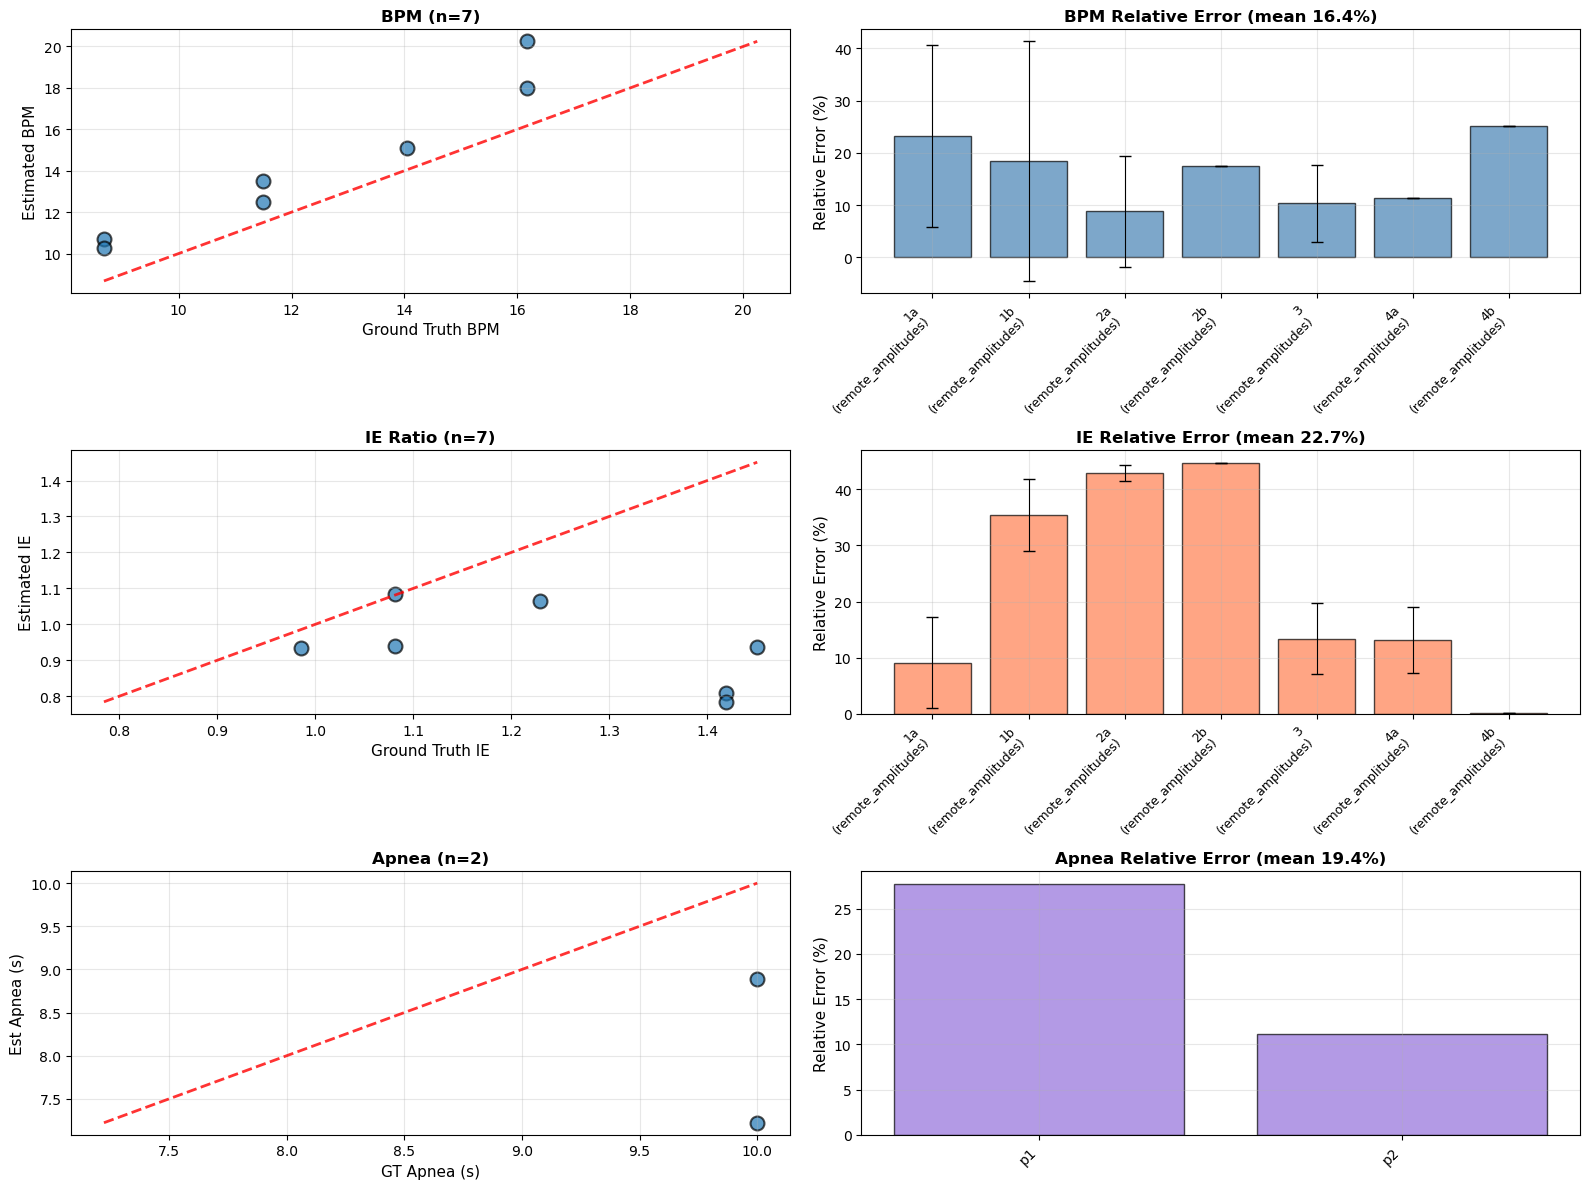

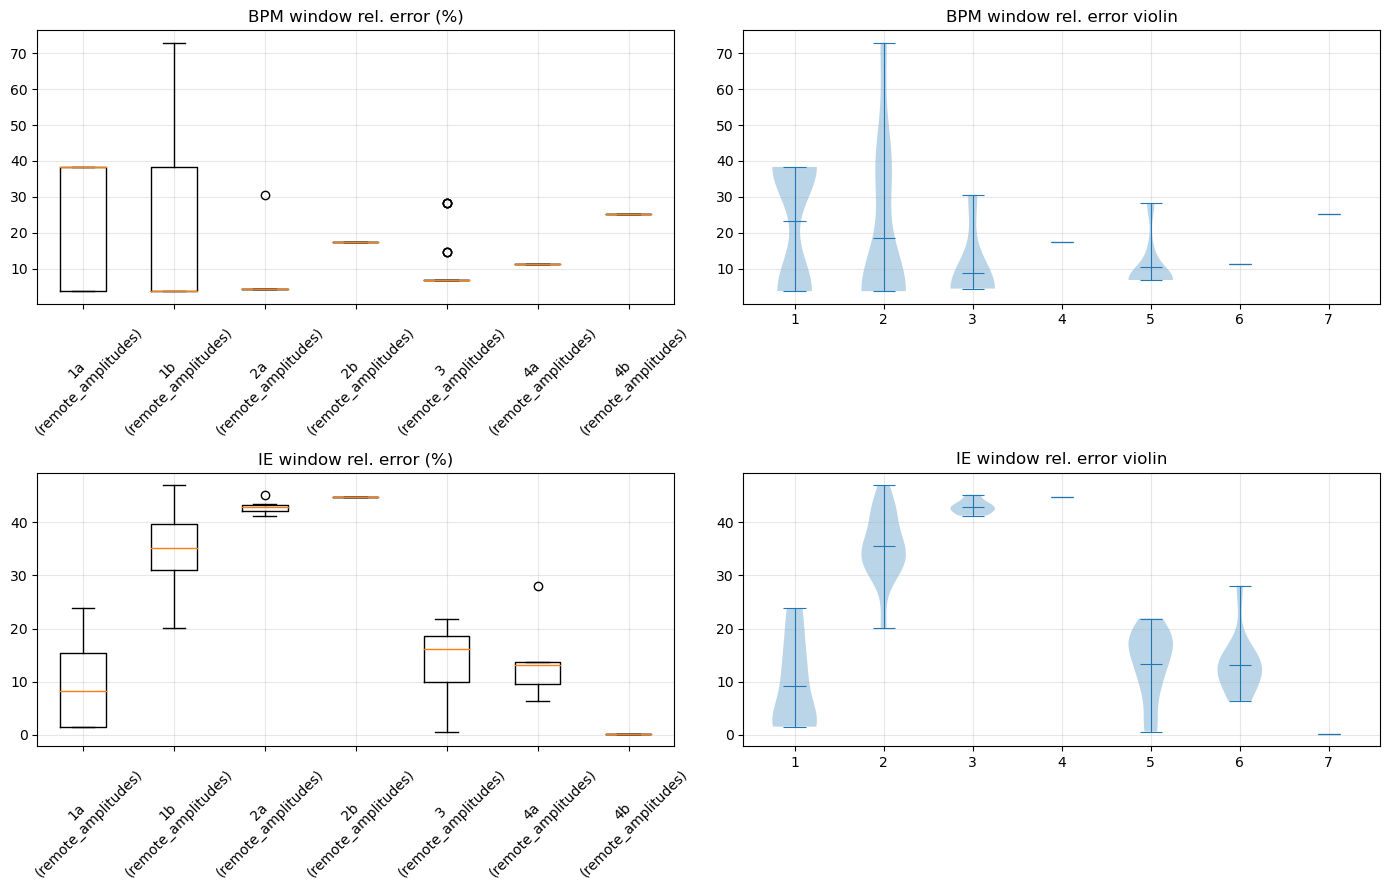

✓ 误差结果已保存 segment_error_results.npy (9 段)


In [4]:
error_out = run_error_analysis(
    segment_processed,
    segment_config,
    segment_data,
    figures_dir=FIGURES_DIR,
    reports_dir=REPORTS_DIR,
    show=True,
    save=True,
)

bpm_data = error_out['bpm_data']
ie_data = error_out['ie_data']
apnea_data = error_out['apnea_data']
error_results = error_out['error_results']
